# Import Libraries

In [943]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Read in Data

In [944]:
Demand = pd.read_excel("../../data/raw/battery/Qtr Hourly Grid Data 2025.xlsx",
                       sheet_name = 'System Data',
                        usecols = ['DateTime', 'TCF 0.3', 'TCF 0.5', 'TCF 0.7'])

Demand["DateTime"] = pd.to_datetime(Demand["DateTime"])
Demand = Demand.set_index("DateTime")

Hourly_Demand = Demand.resample("1h").mean()

Hourly_Demand.head()

,TCF 0.3,TCF 0.5,TCF 0.7
DateTime,,,
2025-01-01 00:00:00,29.810998,49.684996,69.558995
2025-01-01 01:00:00,28.720943,47.868238,67.015533
2025-01-01 02:00:00,27.964897,46.608161,65.251425
2025-01-01 03:00:00,26.980106,44.966843,62.953580
2025-01-01 04:00:00,25.928406,43.214010,60.499615


In [945]:
price_data = pd.read_csv(r"../../data/raw/battery/historical-irish-electricity-prices.csv")
price_data['Timestamp_UTC'] = pd.to_datetime(price_data['Timestamp_UTC'])
price_data = price_data[price_data['Timestamp_UTC'] >= pd.Timestamp.now() - pd.Timedelta(days=365)]


price_data['Date'] = price_data['Timestamp_UTC'].dt.date


In [946]:
# Find most and least expensive 4 hour electricity stretches for each day of last year

def daily_window_hours(group):
    prices = group['Price'].values
    hours  = group['Timestamp_UTC'].dt.hour.values
    n = 4
    if len(prices) < n:
        return pd.Series({'cheap_start': np.nan, 'expensive_start': np.nan})
    avgs = [prices[i:i+n].mean() for i in range(len(prices) - n + 1)]
    low_i  = int(np.argmin(avgs))
    high_i = int(np.argmax(avgs))
    return pd.Series({'cheap_start': hours[low_i], 'expensive_start': hours[high_i]})

windows = price_data.groupby('Date').apply(daily_window_hours, include_groups=False)


In [947]:
L1 = pd.read_excel("../../data/processed/exports/hourly_availability_by_node_phase3.xlsx", 
                   sheet_name='BallinaP3', 
                   usecols=['MWh Available']) # Skips the first 3 rows to make 'Row Labels' the header


L1.head()

,MWh Available
0,500.0
1,500.0
2,500.0
3,500.0
4,500.0


In [948]:
Cork_Constraints = pd.read_excel("../../data/processed/exports/curtailment/new_farms_hourly_constraints_phase3.xlsx",
                            sheet_name='hourly',
                            usecols = ['curtailment_hat_mwh','node_id'])

Cork_Constraints = Cork_Constraints[Cork_Constraints['node_id'] == "BallinaP3"]

Cork_Constraints.tail(5)

,node_id,curtailment_hat_mwh
8755,BallinaP3,14.760834
8756,BallinaP3,22.863508
8757,BallinaP3,45.666693
8758,BallinaP3,78.519781
8759,BallinaP3,78.519781


In [949]:
Hourly_Demand['L1'] = L1['MWh Available'].values

Hourly_Demand.head()

,TCF 0.3,TCF 0.5,TCF 0.7,L1
DateTime,,,,
2025-01-01 00:00:00,29.810998,49.684996,69.558995,500.0
2025-01-01 01:00:00,28.720943,47.868238,67.015533,500.0
2025-01-01 02:00:00,27.964897,46.608161,65.251425,500.0
2025-01-01 03:00:00,26.980106,44.966843,62.953580,500.0
2025-01-01 04:00:00,25.928406,43.214010,60.499615,500.0


In [950]:
Hourly_Demand['TCF 1.0'] = Hourly_Demand['TCF 0.5']*4*0.8

Hourly_Demand.head()

,TCF 0.3,TCF 0.5,TCF 0.7,L1,TCF 1.0
DateTime,,,,,
2025-01-01 00:00:00,29.810998,49.684996,69.558995,500.0,158.991988
2025-01-01 01:00:00,28.720943,47.868238,67.015533,500.0,153.178362
2025-01-01 02:00:00,27.964897,46.608161,65.251425,500.0,149.146115
2025-01-01 03:00:00,26.980106,44.966843,62.953580,500.0,143.893897
2025-01-01 04:00:00,25.928406,43.214010,60.499615,500.0,138.284833


In [951]:
Hourly_Demand['Constraints'] = Cork_Constraints['curtailment_hat_mwh'].values

Hourly_Demand.head()

,TCF 0.3,TCF 0.5,TCF 0.7,L1,TCF 1.0,Constraints
DateTime,,,,,,
2025-01-01 00:00:00,29.810998,49.684996,69.558995,500.0,158.991988,78.519781
2025-01-01 01:00:00,28.720943,47.868238,67.015533,500.0,153.178362,78.519781
2025-01-01 02:00:00,27.964897,46.608161,65.251425,500.0,149.146115,78.519781
2025-01-01 03:00:00,26.980106,44.966843,62.953580,500.0,143.893897,78.519781
2025-01-01 04:00:00,25.928406,43.214010,60.499615,500.0,138.284833,78.519781


In [952]:
Hourly_Demand['TCF 1.0'].max()

np.float64(272.4576900323836)

In [953]:
Hourly_Demand['TCF 1.0'].sum()/(8760*450)

np.float64(0.39996185029640424)

In [954]:
Hourly_Demand['TCF 1.0'].mean()

np.float64(180.00338096454226)

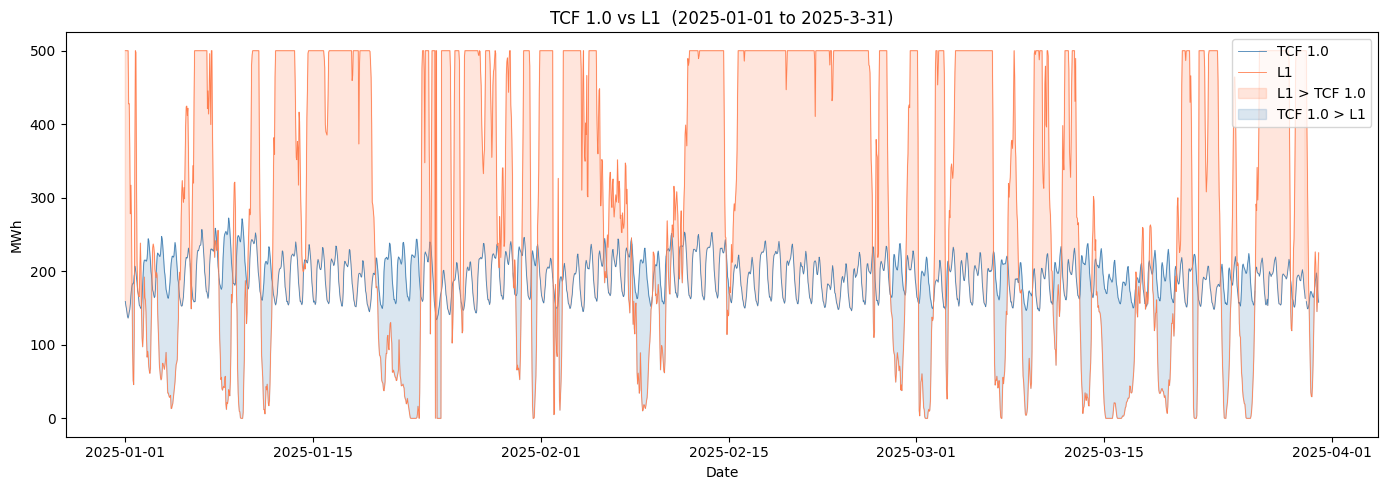

In [955]:
# === CHANGE THESE DATES TO ADJUST THE PLOT RANGE ===
plot_start = '2025-01-01'
plot_end   = '2025-3-31'
# ====================================================

mask = (Hourly_Demand.index >= plot_start) & (Hourly_Demand.index <= plot_end)
plot_data = Hourly_Demand.loc[mask]

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(plot_data.index, plot_data['TCF 1.0'], linewidth=0.6, color='steelblue', label='TCF 1.0')
ax.plot(plot_data.index, plot_data['L1'], linewidth=0.6, color='coral', label='L1')
ax.fill_between(plot_data.index, plot_data['TCF 1.0'], plot_data['L1'], 
                where=plot_data['L1'] > plot_data['TCF 1.0'], alpha=0.2, color='coral', label='L1 > TCF 1.0')
ax.fill_between(plot_data.index, plot_data['TCF 1.0'], plot_data['L1'], 
                where=plot_data['L1'] <= plot_data['TCF 1.0'], alpha=0.2, color='steelblue', label='TCF 1.0 > L1')
ax.set_title(f'TCF 1.0 vs L1  ({plot_start} to {plot_end})')
ax.set_xlabel('Date')
ax.set_ylabel('MWh')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

## Wind Curtailment Data


# Manual Inputs

In [956]:
### Green Hydrogen Electrolyser + Storage Model ###
# Curtailed wind is converted to hydrogen via electrolyser
# Hydrogen is stored and can be withdrawn for downstream use (e.g., fuel cell, industrial)

# Electrolyser Characteristics
P_ely = 15                  # Electrolyser rated power (MW)
ely_efficiency = 50         # Efficiency (kWh/kg H2) — typical range 45–60 kWh/kg
ely_min_load = 0.1          # Minimum load (fraction of P_ely)

# Hydrogen Storage
S_max = 100000              # Maximum storage capacity (kg)
I_max = 500                 # Injection limit (kg/h) — how fast we can store H2
W_max = 500                 # Withdrawal limit (kg/h) — how fast we can extract H2
storage_loss_annual_pct = 2.0  # Annual storage loss (%) — typical for depleted field storage: 1-3%

# Initial storage state
init_storage_kg = S_max * 0.5  # Start at 50% capacity


In [957]:
# Controls

IncludeCurtailment = True   # Include curtailment constraints (True to use curtailed wind as input)

# Electrolyser dispatch strategy
# 'curtailment': Only electrolyse when curtailment > 0 (avoid grid imports)
# 'always': Electrolyse whenever profitable given wind availability
dispatch_mode = 'curtailment'


In [958]:
# Financials

h2_value = 2.00             # €/kg H2 (typical green H2 market value, ~2-4 €/kg)
elec_price = 100            # €/MWh (fallback grid price for minimum load)

capex_ely = 1600000          # €/MW electrolyser (typical: €500k–1.2M/MW)
capex_storage = 100          # €/kg storage (larger systems: €1–10/kg)
ely_min_load_fraction = 0.10  # Electrolyser must run at minimum 10% of rated capacity

# Annual fixed opex (minimum load already accounts for grid costs)

annual_opex_ely = P_ely * 1000 * 43  # from hydrogen observatory: €43/kWh electrolyser capacity (covers maintenance, staffing, etc.)
annual_opex_storage = capex_storage * S_max * 0.01  # 1% of storage capex

# Create Inputs Dataframe

In [959]:
df = pd.DataFrame({
    'Time Stamp': Hourly_Demand.index,
    'Load (MWh)': Hourly_Demand['TCF 1.0'],
    'Generation (MWh)': Hourly_Demand['L1'],
    'Constraints': Hourly_Demand['Constraints']
})

df

,Time Stamp,Load (MWh),Generation (MWh),Constraints
DateTime,,,,
2025-01-01 00:00:00,2025-01-01 00:00:00,158.991988,500.000000,78.519781
2025-01-01 01:00:00,2025-01-01 01:00:00,153.178362,500.000000,78.519781
2025-01-01 02:00:00,2025-01-01 02:00:00,149.146115,500.000000,78.519781
2025-01-01 03:00:00,2025-01-01 03:00:00,143.893897,500.000000,78.519781
2025-01-01 04:00:00,2025-01-01 04:00:00,138.284833,500.000000,78.519781
...,...,...,...,...
2025-12-31 19:00:00,2025-12-31 19:00:00,215.518739,208.438158,14.760834
2025-12-31 20:00:00,2025-12-31 20:00:00,202.497366,291.888982,22.863508
2025-12-31 21:00:00,2025-12-31 21:00:00,192.344535,433.723569,45.666693


In [960]:
print(f"{df['Generation (MWh)'].sum():,}")

2,239,291.443899608


In [961]:
# Calculates remaining load after generation

rem_load = np.maximum(0, df['Load (MWh)'] - df['Generation (MWh)'])
df['Remaining Load'] = rem_load

In [962]:
# Calculates Excess Generation

excess = np.maximum(0, df['Generation (MWh)'] - df['Load (MWh)'])
df['Excess'] = excess

In [963]:
# Initial Hydrogen Storage Level

init_storage_kg


50000.0

In [964]:
# Hydrogen conversion constant

h2_kwh_per_kg = ely_efficiency  # kWh of electricity per kg of H2
h2_energy_mwh_per_kg = h2_kwh_per_kg / 1000  # MWh per kg (for reference)

print(f"Electrolyser Efficiency: {h2_kwh_per_kg} kWh/kg H2")
print(f"H2 Energy Content: 39.4 kWh/kg H2 (LHV)")


Electrolyser Efficiency: 50 kWh/kg H2
H2 Energy Content: 39.4 kWh/kg H2 (LHV)


In [965]:
df['Load (MWh)'] = df['Load (MWh)'].fillna(0)

# For hydrogen model: Curtailment is the input to electrolyser
# If curtailment is disabled for analysis, set to zero
if not IncludeCurtailment:
    df['Constraints'] = np.zeros(len(df))
    
# The curtailed wind (MWh) is our electrolyser feedstock
df['Curtailed Wind (MWh)'] = df['Constraints'].copy()


# Time Series Calculations

In [966]:
# ============================================================
# Build price_arr: hourly prices aligned to simulation year
# ============================================================

price_data['_month'] = price_data['Timestamp_UTC'].dt.month
price_data['_day']   = price_data['Timestamp_UTC'].dt.day
price_data['_hour']  = price_data['Timestamp_UTC'].dt.hour

price_lookup = (
    price_data
    .sort_values('Timestamp_UTC')
    .drop_duplicates(subset=['_month', '_day', '_hour'], keep='last')
    .set_index(['_month', '_day', '_hour'])['Price']
)

price_arr = np.array([
    price_lookup.get((ts.month, ts.day, ts.hour), elec_price)
    for ts in df.index
])

print(f"Price array: {len(price_arr)} hours, "
      f"mean €{price_arr.mean():.2f}/MWh, "
      f"min €{price_arr.min():.2f}/MWh, "
      f"max €{price_arr.max():.2f}/MWh")


Price array: 8760 hours, mean €109.15/MWh, min €-23.50/MWh, max €465.77/MWh


In [967]:
print(f"Total curtailed wind available: {df['Curtailed Wind (MWh)'].sum():,.0f} MWh")


Total curtailed wind available: 281,850 MWh


In [968]:
# Hydrogen is produced in kg from curtailed wind (MWh)
# Conversion: kg_H2 = MWh * (1000 / ely_efficiency)
# Because: 1 MWh = 1000 kWh, so kWh / (kWh/kg) = kg

print("Computing hydrogen electrolyser dispatch...")


Computing hydrogen electrolyser dispatch...


In [969]:
import time
start_time = time.time()

# Convert annual loss (%) to hourly loss factor
# annual_retention = 1 - (annual_loss % / 100)
# hourly_retention = annual_retention ^ (1/8760)
# hourly_loss = 1 - hourly_retention
annual_retention = 1.0 - (storage_loss_annual_pct / 100.0)
storage_loss_hourly = 1.0 - (annual_retention ** (1.0 / 8760.0))

print(f"Storage Loss: {storage_loss_annual_pct}% per year")
print(f"  → Hourly loss factor: {storage_loss_hourly:.6f} ({storage_loss_hourly*100:.4f}% per hour)")
print()

# Extract key arrays
curtailed_wind_mwh = df['Curtailed Wind (MWh)'].values
n = len(df)

# Initialize output arrays
ely_input_mw = np.zeros(n)           # Electrical input to electrolyser (MW)
ely_curtail_mw = np.zeros(n)         # Curtailed wind used (MW)
ely_grid_mw = np.zeros(n)            # Grid electricity used (MW)
h2_produced_kg = np.zeros(n)         # Hydrogen produced (kg)
h2_injected_kg = np.zeros(n)         # H2 injected to storage (kg)
h2_withdrawn_kg = np.zeros(n)        # H2 withdrawn from storage (kg)
storage_level_kg = np.zeros(n)       # Storage inventory at end of hour (kg)
h2_spilled_kg = np.zeros(n)          # H2 that couldn't be injected (overflow)
grid_cost_hourly = np.zeros(n)       # Cost of grid electricity used (€)

# Minimum electrolyser load (MW)
min_ely_load_mw = P_ely * ely_min_load_fraction

prev_storage = init_storage_kg

for i in range(n):
    # Hour's available curtailed wind (MWh) = power in MW for 1-hour interval
    curtail_mwh = curtailed_wind_mwh[i]
    
    # ===== ELECTROLYSER OPERATION WITH MINIMUM LOAD & GRID BACKUP =====
    # Electrolyser MUST run at minimum 10% of rated capacity
    # Priority 1: Use free curtailed wind
    # Priority 2: If shortfall, use grid electricity at spot price
    # Priority 3: Can use additional curtailed wind if available (up to rated capacity)
    
    available_storage_space = S_max - prev_storage
    
    # ===== Step 1: Meet minimum load with curtailed wind + grid electricity =====
    # Use as much curtailed wind as possible for minimum load
    curtail_for_min_load = min(curtail_mwh, min_ely_load_mw)  # Free curtailed wind
    grid_for_min_load = max(0, min_ely_load_mw - curtail_for_min_load)  # Grid deficit
    
    # Cost of grid backup for minimum load
    grid_cost_for_min_load = grid_for_min_load * price_arr[i]
    
    # ===== Step 2: Check remaining available power =====
    # After meeting minimum load, remaining curtailed wind can be used
    remaining_curtail = curtail_mwh - curtail_for_min_load
    max_additional_curtail = min(remaining_curtail, P_ely - min_ely_load_mw)  # Up to rated capacity
    
    # Total electrolyser input:
    # - Minimum load (curtailed + grid mix)
    # - Plus additional curtailed wind if available
    total_ely_input = min_ely_load_mw + max_additional_curtail
    total_ely_input = min(total_ely_input, P_ely)  # Cap at rated power
    
    ely_input_mw[i] = total_ely_input
    ely_curtail_mw[i] = curtail_for_min_load + max_additional_curtail
    ely_grid_mw[i] = grid_for_min_load
    grid_cost_hourly[i] = grid_cost_for_min_load
    
    # ===== Step 3: Produce H2 =====
    # Hydrogen produced from total electrical input
    h2_from_ely_input = (total_ely_input * 1000) / ely_efficiency  # kg
    
    # Limit by storage space and injection rate
    max_h2_space = available_storage_space
    h2_prod = min(h2_from_ely_input, max_h2_space, I_max)
    
    h2_produced_kg[i] = h2_prod
    h2_injected_kg[i] = h2_prod  # All produced H2 goes to storage
    
    # ===== Step 4: Withdrawal & Dispatch =====
    # Simple strategy: withdraw H2 whenever storage is above 50% capacity
    withdrawal_threshold = S_max * 0.5
    
    if prev_storage > withdrawal_threshold:
        h2_with = min(prev_storage - withdrawal_threshold, W_max)
    else:
        h2_with = 0.0
    
    h2_withdrawn_kg[i] = h2_with
    
    # ===== Step 5: Update Storage Inventory =====
    # Storage balance: S_t+1 = S_t + inj - with - losses
    new_storage = prev_storage + h2_prod - h2_with
    new_storage = new_storage * (1 - storage_loss_hourly)  # Apply hourly loss factor
    
    # Clamp to limits
    if new_storage > S_max:
        h2_spilled_kg[i] = new_storage - S_max
        new_storage = S_max
    else:
        h2_spilled_kg[i] = 0.0
    
    if new_storage < 0:
        new_storage = 0.0
    
    storage_level_kg[i] = new_storage
    prev_storage = new_storage

# Add output arrays to dataframe
df['Electrolyser Input (MW)'] = ely_input_mw
df['H2 Produced (kg)'] = h2_produced_kg
df['H2 Injected (kg)'] = h2_injected_kg
df['H2 Withdrawn (kg)'] = h2_withdrawn_kg
df['Storage Level (kg)'] = storage_level_kg
df['H2 Spilled (kg)'] = h2_spilled_kg

# Calculate total curtailed wind used (sum of hourly curtailed wind, in MWh)
total_curtailed_wind_used = ely_curtail_mw.sum()

print(f"Simulation complete: {time.time() - start_time:.1f}s")

Storage Loss: 2.0% per year
  → Hourly loss factor: 0.000002 (0.0002% per hour)

Simulation complete: 0.1s


# Data Table (First 10 Hours)


# Results Summary


In [970]:
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

cols_to_show = [
    "Time Stamp",
    "Curtailed Wind (MWh)",
    "Electrolyser Input (MW)",
    "H2 Produced (kg)",
    "H2 Injected (kg)",
    "H2 Withdrawn (kg)",
    "Storage Level (kg)",
    "H2 Spilled (kg)",
]

missing = [c for c in cols_to_show if c not in df.columns]
if missing:
    print("Missing columns:", missing)
else:
    display(df.loc[:, cols_to_show].head(10))


,Time Stamp,Curtailed Wind (MWh),Electrolyser Input (MW),H2 Produced (kg),H2 Injected (kg),H2 Withdrawn (kg),Storage Level (kg),H2 Spilled (kg)
DateTime,,,,,,,,
2025-01-01 00:00:00,2025-01-01 00:00:00,78.519781,15.0,300.0,300.0,0.000000,50299.883996,0.0
2025-01-01 01:00:00,2025-01-01 01:00:00,78.519781,15.0,300.0,300.0,299.883996,50299.883996,0.0
2025-01-01 02:00:00,2025-01-01 02:00:00,78.519781,15.0,300.0,300.0,299.883996,50299.883996,0.0
2025-01-01 03:00:00,2025-01-01 03:00:00,78.519781,15.0,300.0,300.0,299.883996,50299.883996,0.0
2025-01-01 04:00:00,2025-01-01 04:00:00,78.519781,15.0,300.0,300.0,299.883996,50299.883996,0.0
2025-01-01 05:00:00,2025-01-01 05:00:00,78.519781,15.0,300.0,300.0,299.883996,50299.883996,0.0
2025-01-01 06:00:00,2025-01-01 06:00:00,45.028940,15.0,300.0,300.0,299.883996,50299.883996,0.0
2025-01-01 07:00:00,2025-01-01 07:00:00,45.060504,15.0,300.0,300.0,299.883996,50299.883996,0.0
2025-01-01 08:00:00,2025-01-01 08:00:00,35.023309,15.0,300.0,300.0,299.883996,50299.883996,0.0


In [971]:
# Curtailment Availability Summary

total_curtailed_mwh = df['Curtailed Wind (MWh)'].sum()
max_curtailment_mw = df['Curtailed Wind (MWh)'].max()
avg_curtailment_mw = df['Curtailed Wind (MWh)'].mean()
hours_with_curtailment = (df['Curtailed Wind (MWh)'] > 0).sum()

summary = pd.DataFrame({
    'Metric': [
        'Total Curtailed Wind (Annual)',
        'Max Curtailment Rate',
        'Avg Curtailment Rate',
        'Hours with Curtailment',
        'Curtailment Utilization'
    ],
    'Value': [
        f"{total_curtailed_mwh:,.0f} MWh",
        f"{max_curtailment_mw:,.1f} MW",
        f"{avg_curtailment_mw:,.2f} MW",
        f"{hours_with_curtailment:,.0f} hrs",
        f"{hours_with_curtailment / 8760 * 100:.1f}%"
    ]
})

summary.style.hide(axis='index')


Metric,Value
Total Curtailed Wind (Annual),"281,850 MWh"
Max Curtailment Rate,78.5 MW
Avg Curtailment Rate,32.17 MW
Hours with Curtailment,"8,161 hrs"
Curtailment Utilization,93.2%


# Hydrogen Production & Storage Summary


In [972]:
# Hydrogen Production & Storage Summary

total_h2_produced = h2_produced_kg.sum()
total_h2_withdrawn = h2_withdrawn_kg.sum()
total_h2_spilled = h2_spilled_kg.sum()

# Energy equivalents (1 kg H2 ≈ 39.4 kWh)
h2_energy_content = 39.4  # kWh/kg
total_h2_energy_mwh = total_h2_produced * h2_energy_content / 1000

# Electrolyser utilization
total_ely_input_mwh = ely_input_mw.sum()
max_ely_capacity_mwh = P_ely * 8760
ely_hours_active = (ely_input_mw > 0).sum()
ely_capacity_factor = (total_ely_input_mwh / max_ely_capacity_mwh * 100) if max_ely_capacity_mwh > 0 else 0

# Storage cycling
max_storage = S_max
storage_cycles = total_h2_withdrawn / max_storage if max_storage > 0 else 0

# Curtailment captured (% of total available curtailment actually used by electrolyser)
# Note: This only counts curtailed wind, not grid backup electricity
curtailment_captured = (total_curtailed_wind_used / total_curtailed_mwh * 100) if total_curtailed_mwh > 0 else 0

h2_summary = pd.DataFrame({
    'Metric': [
        'Total H2 Produced (Annual)',
        'H2 Energy Equivalent',
        'Total H2 Withdrawn',
        'Total H2 Spilled (Unused)',
        'Electrolyser Utilization',
        'Electrolyser Capacity Factor',
        'Hours Electrolyser Active',
        'Storage Cycles/Year',
        'Curtailment Captured',
        'Max Storage Level',
        'Initial Storage Level'
    ],
    'Value': [
        f"{total_h2_produced:,.0f} kg",
        f"{total_h2_energy_mwh:,.0f} MWh",
        f"{total_h2_withdrawn:,.0f} kg",
        f"{total_h2_spilled:,.0f} kg",
        f"{total_ely_input_mwh:,.0f} MWh",
        f"{ely_capacity_factor:.1f}%",
        f"{ely_hours_active:,.0f} hrs",
        f"{storage_cycles:.2f}",
        f"{curtailment_captured:.1f}%",
        f"{storage_level_kg.max():,.0f} kg",
        f"{init_storage_kg:,.0f} kg"
    ]
})

h2_summary.style.hide(axis='index')

Metric,Value
Total H2 Produced (Annual),"1,659,167 kg"
H2 Energy Equivalent,"65,371 MWh"
Total H2 Withdrawn,"1,657,853 kg"
Total H2 Spilled (Unused),0 kg
Electrolyser Utilization,"82,958 MWh"
Electrolyser Capacity Factor,63.1%
Hours Electrolyser Active,"8,760 hrs"
Storage Cycles/Year,16.58
Curtailment Captured,28.5%
Max Storage Level,"50,300 kg"


In [973]:
# Electrolyser and Withdrawal Statistics

active_ely = ely_input_mw > 0
active_with = h2_withdrawn_kg > 0

avg_ely_power_when_active = ely_input_mw[active_ely].mean() if active_ely.sum() > 0 else 0
avg_h2_production_when_active = h2_produced_kg[active_ely].mean() if active_ely.sum() > 0 else 0
avg_h2_withdrawal_when_active = h2_withdrawn_kg[active_with].mean() if active_with.sum() > 0 else 0

print(f"Electrolyser Statistics:")
print(f"  Average Power (when active):       {avg_ely_power_when_active:,.2f} MW")
print(f"  Average H2 Production (when active): {avg_h2_production_when_active:,.0f} kg/h")
print()
print(f"Storage Withdrawal Statistics:")
print(f"  Average H2 Withdrawal (when active): {avg_h2_withdrawal_when_active:,.0f} kg/h")
print(f"  Max Storage Level:                 {storage_level_kg.max():,.0f} kg")
print(f"  Min Storage Level:                 {storage_level_kg.min():,.0f} kg")


Electrolyser Statistics:
  Average Power (when active):       9.47 MW
  Average H2 Production (when active): 189 kg/h

Storage Withdrawal Statistics:
  Average H2 Withdrawal (when active): 189 kg/h
  Max Storage Level:                 50,300 kg
  Min Storage Level:                 50,030 kg


In [974]:
hours_with_curtailment = (df['Curtailed Wind (MWh)'] > 0).sum()
hours_ely_at_rated = (ely_input_mw >= P_ely * 0.95).sum()  # 95% of rated
hours_storage_full = (storage_level_kg >= S_max * 0.95).sum()  # 95% full
hours_storage_empty = (storage_level_kg <= S_max * 0.05).sum()  # 5% or less

print(f"Operational Hours:")
print(f"  Hours with curtailed wind available: {hours_with_curtailment}")
print(f"  Hours electrolyser near rated power: {hours_ely_at_rated}")
print(f"  Hours storage near full: {hours_storage_full}")
print(f"  Hours storage near empty: {hours_storage_empty}")


Operational Hours:
  Hours with curtailed wind available: 8161
  Hours electrolyser near rated power: 4552
  Hours storage near full: 0
  Hours storage near empty: 0


In [975]:
# === Hydrogen Economics Calculations ===

# H2 Revenue: all withdrawn H2 sold at market price
h2_revenue_arr = h2_withdrawn_kg * h2_value
total_h2_revenue = h2_revenue_arr.sum()

# Grid electricity cost: only pay for grid electricity used (curtailed wind is free)
# Grid costs are already calculated hourly as grid_cost_hourly
total_grid_cost = grid_cost_hourly.sum()

# Add revenue/cost columns to dataframe
df['H2 Revenue (€)'] = h2_revenue_arr
df['Grid Cost (€/hour)'] = grid_cost_hourly

# Capital and Operating Costs
capex_electrolyser = capex_ely * P_ely           # Total electrolyser capex (€)
capex_storage_total =   S_max * capex_storage   # Total storage capex (€)
capex_total = capex_electrolyser + capex_storage_total

# Operating costs (annual)
opex_ely_annual = annual_opex_ely
opex_storage_annual = annual_opex_storage
opex_total_annual = opex_ely_annual + opex_storage_annual

# Annual hydrogen economics
gross_h2_revenue = total_h2_revenue
net_annual_revenue = (gross_h2_revenue 
                      - total_grid_cost
                      - opex_total_annual)

# Payback analysis
simple_payback = capex_total / net_annual_revenue if net_annual_revenue > 0 else float('inf')

# 20-year NPV calculation
inflation_rate = 0.02
discount_rate = 0.06
degradation_rate = 0.01  # Slight annual degradation of electrolyser efficiency
term = 20

npv = -capex_total + sum(
    net_annual_revenue * (1 - degradation_rate)**yr * (1 + inflation_rate)**yr / (1 + discount_rate)**yr
    for yr in range(1, term + 1)
)

# Print summary
print("="*70)
print("HYDROGEN ECONOMICS SUMMARY")
print("="*70)
print(f"\nCapital Expenditure:")
print(f"  Electrolyser (€{capex_ely:,.0f}/MW × {P_ely} MW):  €{capex_electrolyser:>12,.0f}")
print(f"  Storage (€{capex_storage}/kg × {S_max:,.0f} kg):        €{capex_storage_total:>12,.0f}")
print(f"  Total CapEx:                          €{capex_total:>12,.0f}")
print()
print(f"Annual Revenue & Costs:")
print(f"  H2 Revenue (€{h2_value:.2f}/kg × {total_h2_withdrawn:,.0f} kg): €{gross_h2_revenue:>12,.0f}")
print(f"  Grid Electricity Cost:               -€{total_grid_cost:>12,.0f}")
print(f"  Electrolyser OpEx:                   -€{opex_ely_annual:>12,.0f}")
print(f"  Storage OpEx:                        -€{opex_storage_annual:>12,.0f}")
print(f"  Net Annual Revenue:                  €{net_annual_revenue:>12,.0f}")
print()
print(f"Investment Metrics:")
print(f"  Simple Payback Period:                {simple_payback:>11.2f} years")
print(f"  20-Year NPV (at {discount_rate*100:.0f}% discount):      €{npv:>12,.0f}")
print("="*70)


HYDROGEN ECONOMICS SUMMARY

Capital Expenditure:
  Electrolyser (€1,600,000/MW × 15 MW):  €  24,000,000
  Storage (€100/kg × 100,000 kg):        €  10,000,000
  Total CapEx:                          €  34,000,000

Annual Revenue & Costs:
  H2 Revenue (€2.00/kg × 1,657,853 kg): €   3,315,705
  Grid Electricity Cost:               -€     341,975
  Electrolyser OpEx:                   -€     645,000
  Storage OpEx:                        -€     100,000
  Net Annual Revenue:                  €   2,228,730

Investment Metrics:
  Simple Payback Period:                      15.26 years
  20-Year NPV (at 6% discount):      €  -6,157,337


Running grid search optimization (this may take ~30s)...

Optimization Results:
  Optimal Electrolyser Size: 15 MW
  Optimal Storage Capacity:  10,000 kg
  Maximum 20-Year NPV:       €6,050,991
  Total CapEx:               €25,000,000


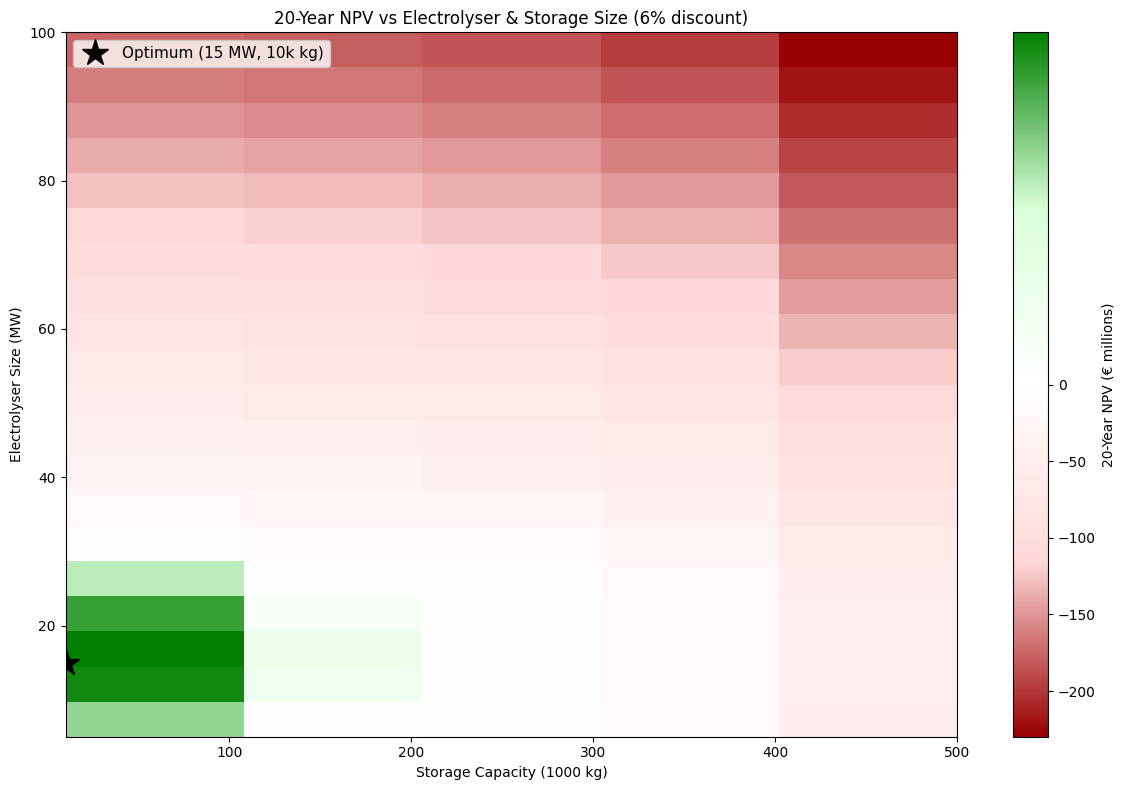

In [976]:
# === Optimise Electrolyser Size (P_ely) and Storage Capacity (S_max) to maximise 20-Year NPV ===

import itertools
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm

def simulate_h2_npv(ely_size_mw, storage_capacity_kg):
    """
    Run hydrogen electrolyser + storage simulation with 10% minimum load and return 20-year NPV.
    
    Model:
    - Curtailed wind is free
    - Must run electrolyser at minimum 10% load (use grid if curtailed wind insufficient)
    - Can use additional curtailed wind up to rated capacity (free)
    - Only pay for grid electricity needed to meet 10% minimum
    """
    # Convert annual loss (%) to hourly loss factor
    annual_retention_l = 1.0 - (storage_loss_annual_pct / 100.0)
    storage_loss_hourly_l = 1.0 - (annual_retention_l ** (1.0 / 8760.0))
    
    # Local params for this simulation
    p_ely_l = ely_size_mw
    s_max_l = storage_capacity_kg
    init_storage_l = s_max_l * 0.5
    min_load_l = p_ely_l * ely_min_load_fraction
    
    # Pre-compute capex
    capex_ely_l = capex_ely * p_ely_l
    capex_storage_l = capex_storage * s_max_l
    capex_total_l = capex_ely_l + capex_storage_l
    
    # Annual opex
    opex_ely_l = capex_ely_l * 0.02
    opex_storage_l = capex_storage_l * 0.01
    opex_total_l = opex_ely_l + opex_storage_l
    
    # Arrays for this simulation
    n_l = len(df)
    curtail_mwh_l = df['Curtailed Wind (MWh)'].values
    
    prev_stor_l = init_storage_l
    total_h2_withdrawn_l = 0.0
    total_grid_cost_l = 0.0
    
    # Sequential simulation
    for i in range(n_l):
        curtail_l = curtail_mwh_l[i]
        
        # ===== Step 1: Meet minimum load with curtailed wind + grid =====
        curtail_for_min = min(curtail_l, min_load_l)
        grid_for_min = max(0, min_load_l - curtail_for_min)
        
        # ===== Step 2: Additional curtailed wind =====
        remaining_curtail = curtail_l - curtail_for_min
        additional_curtail = min(remaining_curtail, p_ely_l - min_load_l)
        
        # Total electrolyser input
        total_ely_input = min(min_load_l + additional_curtail, p_ely_l)
        
        # Grid cost only for grid electricity
        grid_cost = grid_for_min * price_arr[i]
        total_grid_cost_l += grid_cost
        
        # ===== Step 3: Produce H2 =====
        avail_space_l = s_max_l - prev_stor_l
        h2_prod_l = (total_ely_input * 1000) / ely_efficiency
        h2_prod_l = min(h2_prod_l, avail_space_l, I_max)
        
        # ===== Step 4: Withdrawal =====
        thresh_l = s_max_l * 0.5
        if prev_stor_l > thresh_l:
            h2_with_l = min(prev_stor_l - thresh_l, W_max)
        else:
            h2_with_l = 0.0
        
        total_h2_withdrawn_l += h2_with_l
        
        # ===== Step 5: Update storage =====
        new_stor_l = prev_stor_l + h2_prod_l - h2_with_l
        new_stor_l = new_stor_l * (1 - storage_loss_hourly_l)
        new_stor_l = max(0, min(new_stor_l, s_max_l))
        prev_stor_l = new_stor_l
    
    # Annual revenue
    gross_rev_l = total_h2_withdrawn_l * h2_value
    net_annual_rev_l = gross_rev_l - total_grid_cost_l - opex_total_l
    
    # 20-year NPV
    npv_l = -capex_total_l + sum(
        net_annual_rev_l * (1 - degradation_rate)**yr * (1 + inflation_rate)**yr / (1 + discount_rate)**yr
        for yr in range(1, term + 1)
    )
    
    return npv_l


# Grid search parameters
ely_size_range = np.arange(5, 101, 5)    # MW: 5, 10, 15 … 100
storage_cap_range = np.array([10000, 50000, 100000, 200000, 500000])  # kg

# Grid search
best_npv = -np.inf
best_ely_size = None
best_storage_cap = None
results = np.full((len(ely_size_range), len(storage_cap_range)), np.nan)

print("Running grid search optimization (this may take ~30s)...")
for i, ely_sz in enumerate(ely_size_range):
    for j, stor_cap in enumerate(storage_cap_range):
        npv_val = simulate_h2_npv(ely_sz, stor_cap)
        results[i, j] = npv_val
        if npv_val > best_npv:
            best_npv = npv_val
            best_ely_size = ely_sz
            best_storage_cap = stor_cap

print(f"\nOptimization Results:")
print(f"  Optimal Electrolyser Size: {best_ely_size} MW")
print(f"  Optimal Storage Capacity:  {best_storage_cap:,.0f} kg")
print(f"  Maximum 20-Year NPV:       €{best_npv:,.0f}")
capex_opt = best_ely_size * capex_ely + best_storage_cap * capex_storage
print(f"  Total CapEx:               €{capex_opt:,.0f}")

# Heatmap
red_green_cmap = LinearSegmentedColormap.from_list(
    'RedGreen',
    [(0.6, 0, 0), (1, 0.85, 0.85), (1, 1, 1), (0.85, 1, 0.85), (0, 0.5, 0)],
    N=256
)

results_M = results / 1e6
vmin, vmax = np.nanmin(results_M), np.nanmax(results_M)

if vmin < 0 < vmax:
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)
elif vmin >= 0:
    norm = TwoSlopeNorm(vmin=-0.01, vcenter=0, vmax=vmax)
else:
    norm = TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=0.01)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(results_M, origin='lower', aspect='auto',
               extent=[storage_cap_range[0]/1000, storage_cap_range[-1]/1000, 
                      ely_size_range[0], ely_size_range[-1]],
               cmap=red_green_cmap, norm=norm)
cbar = fig.colorbar(im, ax=ax, label='20-Year NPV (€ millions)')
ax.set_xlabel('Storage Capacity (1000 kg)')
ax.set_ylabel('Electrolyser Size (MW)')
ax.set_title(f'{term}-Year NPV vs Electrolyser & Storage Size ({discount_rate*100:.0f}% discount)')
ax.plot(best_storage_cap/1000, best_ely_size, 'k*', markersize=20,
        label=f'Optimum ({best_ely_size} MW, {best_storage_cap/1000:.0f}k kg)')
ax.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.show()


# Sensitivity Analysis: Electrolyser CapEx


SENSITIVITY ANALYSIS: ELECTROLYSER CAPEX

Testing capex_ely values (€/MW): [ 800000 1000000 1200000 1400000 1600000]

 CapEx (€/MW)  Total CapEx (€)  Annual OpEx (€)  Gross H2 Revenue (€)  Net Annual Revenue (€)  Simple Payback (yrs)  20-Year NPV (€)
       800000         22000000         340000.0          3.315705e+06            2.633730e+06              8.353171     1.090217e+07
      1000000         25000000         400000.0          3.315705e+06            2.573730e+06              9.713528     7.152615e+06
      1200000         28000000         460000.0          3.315705e+06            2.513730e+06             11.138824     3.403058e+06
      1400000         31000000         520000.0          3.315705e+06            2.453730e+06             12.633826    -3.464989e+05
      1600000         34000000         580000.0          3.315705e+06            2.393730e+06             14.203772    -4.096056e+06

SENSITIVITY ANALYSIS SUMMARY
Optimal Electrolyser CapEx:        €800,000/MW
Maximum

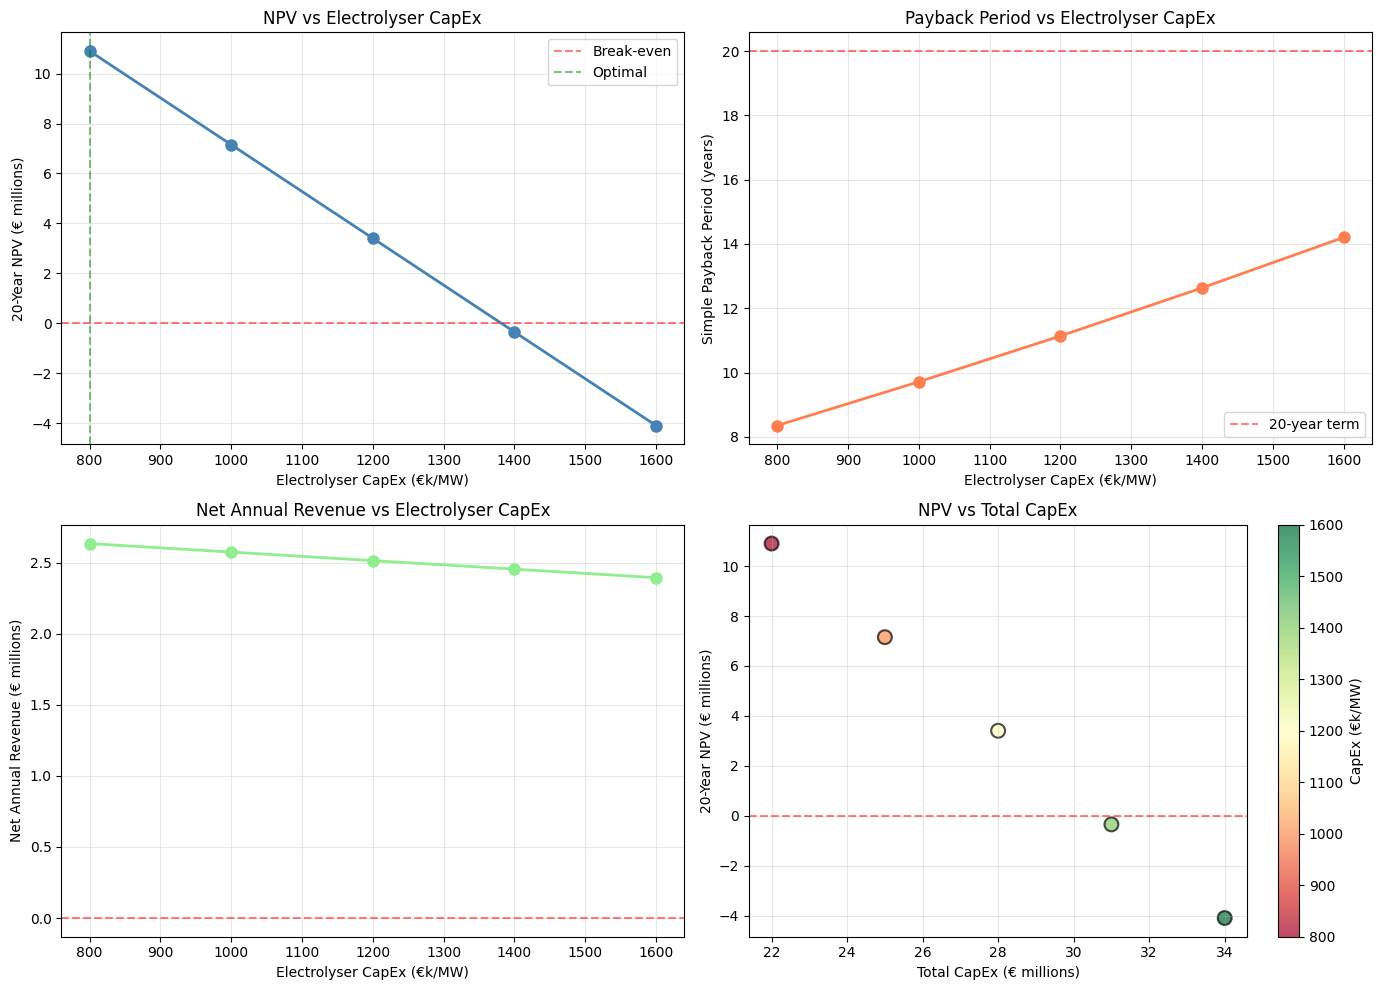

In [977]:
# === Sensitivity Analysis: Electrolyser CapEx ===

# Define capex range: €400k to €1.2M in €200k increments
capex_ely_range = np.arange(800000, 1800000, 200000)

print("="*80)
print("SENSITIVITY ANALYSIS: ELECTROLYSER CAPEX")
print("="*80)
print(f"\nTesting capex_ely values (€/MW): {capex_ely_range.astype(int)}")
print()

# Store results
sensitivity_results = []

# Current values (from main simulation)
current_h2_withdrawn = total_h2_withdrawn
current_grid_cost = total_grid_cost
current_opex = opex_total_annual

# Loop through capex range
for test_capex_ely in capex_ely_range:
    # Recalculate capex and opex with new electrolyser capex
    test_capex_electrolyser = test_capex_ely * P_ely
    test_capex_storage = capex_storage * S_max
    test_capex_total = test_capex_electrolyser + test_capex_storage
    
    # OpEx adjusts with electrolyser capex
    test_opex_ely_annual = test_capex_ely * P_ely * 0.02  # 2% of capex
    test_opex_storage_annual = capex_storage * S_max * 0.01  # 1% of storage capex
    test_opex_total_annual = test_opex_ely_annual + test_opex_storage_annual
    
    # Revenue stays fixed (same H2 production)
    test_gross_h2_revenue = current_h2_withdrawn * h2_value
    
    # Annual economics with test capex
    test_net_annual_revenue = (test_gross_h2_revenue 
                               - current_grid_cost 
                               - test_opex_total_annual)
    
    # Simple payback
    test_simple_payback = test_capex_total / test_net_annual_revenue if test_net_annual_revenue > 0 else np.inf
    
    # 20-year NPV
    test_npv = -test_capex_total + sum(
        test_net_annual_revenue * (1 - degradation_rate)**yr * (1 + inflation_rate)**yr / (1 + discount_rate)**yr
        for yr in range(1, term + 1)
    )
    
    # Store results
    sensitivity_results.append({
        'CapEx (€/MW)': test_capex_ely,
        'Total CapEx (€)': test_capex_total,
        'Annual OpEx (€)': test_opex_total_annual,
        'Gross H2 Revenue (€)': test_gross_h2_revenue,
        'Net Annual Revenue (€)': test_net_annual_revenue,
        'Simple Payback (yrs)': test_simple_payback,
        '20-Year NPV (€)': test_npv
    })

# Create results dataframe
sensitivity_df = pd.DataFrame(sensitivity_results)

print(sensitivity_df.to_string(index=False))
print()

# Find optimal capex (maximum NPV)
opt_idx = sensitivity_df['20-Year NPV (€)'].idxmax()
opt_capex_row = sensitivity_df.loc[opt_idx]

print("="*80)
print("SENSITIVITY ANALYSIS SUMMARY")
print("="*80)
print(f"Optimal Electrolyser CapEx:        €{opt_capex_row['CapEx (€/MW)']:,.0f}/MW")
print(f"Maximum 20-Year NPV:               €{opt_capex_row['20-Year NPV (€)']:,.0f}")
print(f"Simple Payback at Optimum:         {opt_capex_row['Simple Payback (yrs)']:.2f} years")
print(f"Net Annual Revenue at Optimum:     €{opt_capex_row['Net Annual Revenue (€)']:,.0f}")
print()

# Plot sensitivity
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: NPV vs CapEx
ax1 = axes[0, 0]
ax1.plot(sensitivity_df['CapEx (€/MW)'] / 1000, sensitivity_df['20-Year NPV (€)'] / 1e6, 
         'o-', color='steelblue', linewidth=2, markersize=8)
ax1.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='Break-even')
ax1.axvline(x=opt_capex_row['CapEx (€/MW)'] / 1000, color='green', linestyle='--', alpha=0.5, label='Optimal')
ax1.set_xlabel('Electrolyser CapEx (€k/MW)')
ax1.set_ylabel('20-Year NPV (€ millions)')
ax1.set_title('NPV vs Electrolyser CapEx')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot 2: Simple Payback vs CapEx
ax2 = axes[0, 1]
ax2.plot(sensitivity_df['CapEx (€/MW)'] / 1000, sensitivity_df['Simple Payback (yrs)'], 
         'o-', color='coral', linewidth=2, markersize=8)
ax2.axhline(y=20, color='red', linestyle='--', alpha=0.5, label='20-year term')
ax2.set_xlabel('Electrolyser CapEx (€k/MW)')
ax2.set_ylabel('Simple Payback Period (years)')
ax2.set_title('Payback Period vs Electrolyser CapEx')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot 3: Net Annual Revenue vs CapEx
ax3 = axes[1, 0]
ax3.plot(sensitivity_df['CapEx (€/MW)'] / 1000, sensitivity_df['Net Annual Revenue (€)'] / 1e6, 
         'o-', color='lightgreen', linewidth=2, markersize=8)
ax3.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax3.set_xlabel('Electrolyser CapEx (€k/MW)')
ax3.set_ylabel('Net Annual Revenue (€ millions)')
ax3.set_title('Net Annual Revenue vs Electrolyser CapEx')
ax3.grid(True, alpha=0.3)

# Plot 4: Total CapEx vs NPV
ax4 = axes[1, 1]
scatter = ax4.scatter(sensitivity_df['Total CapEx (€)'] / 1e6, 
                     sensitivity_df['20-Year NPV (€)'] / 1e6,
                     s=100, c=sensitivity_df['CapEx (€/MW)'] / 1000, 
                     cmap='RdYlGn', alpha=0.7, edgecolors='black', linewidth=1.5)
ax4.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax4.set_xlabel('Total CapEx (€ millions)')
ax4.set_ylabel('20-Year NPV (€ millions)')
ax4.set_title('NPV vs Total CapEx')
ax4.grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('CapEx (€k/MW)')

plt.tight_layout()
plt.show()

print("="*80)

# Carbon Offset Analysis


In [978]:
# === Executive Summary Table ===

summary_table = pd.DataFrame({
    'Metric': [
        'Dispatch Down Captured',
        'Curtailment Offset %',
        'Carbon Offset',
        'H2 Revenue',
        'Grid Electricity Cost',
        'Annual OpEx',
        'Net Annual Revenue',
        'Initial CapEx Cost',
        'Simple Payback Period',
        '20-Year NPV'
    ],
    'Value': [
        f"{total_curtailed_wind_used:,.0f} MWh/year",
        f"{curtailment_captured:.1f}%",
        f"{co2_avoided_tonnes:,.0f} tonnes CO₂/year",
        f"€{gross_h2_revenue:,.0f}",
        f"€{total_grid_cost:,.0f}",
        f"€{opex_total_annual:,.0f}",
        f"€{net_annual_revenue:,.0f}",
        f"€{capex_total:,.0f}",
        f"{simple_payback:.2f} years",
        f"€{npv:,.0f}"
    ]
})

print("\n" + "="*80)
print("HYDROGEN PROJECT EXECUTIVE SUMMARY")
print("="*80)
print()
display(summary_table.style.hide(axis='index'))
print()
print("="*80)



HYDROGEN PROJECT EXECUTIVE SUMMARY



Metric,Value
Dispatch Down Captured,"80,445 MWh/year"
Curtailment Offset %,28.5%
Carbon Offset,"17,939 tonnes CO₂/year"
H2 Revenue,"€3,315,705"
Grid Electricity Cost,"€341,975"
Annual OpEx,"€745,000"
Net Annual Revenue,"€2,228,730"
Initial CapEx Cost,"€34,000,000"
Simple Payback Period,15.26 years
20-Year NPV,"€-6,157,337"
